In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model12_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model12_0)
describe(model12_0)

MACs: 4.25 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16,

Loading checkpoint from model_weights/model12_0.pt
Starting
Epoch 1/60: Train loss = 1.1096, Train accuracy = 0.6041, Test loss = 1.0653, Test accuracy = 0.6199
Epoch 2/60: Train loss = 0.9140, Train accuracy = 0.6747, Test loss = 0.8703, Test accuracy = 0.6923
Epoch 3/60: Train loss = 0.8506, Train accuracy = 0.7037, Test loss = 0.8507, Test accuracy = 0.7012
Epoch 4/60: Train loss = 0.7657, Train accuracy = 0.7299, Test loss = 0.7593, Test accuracy = 0.7362
Epoch 5/60: Train loss = 0.7791, Train accuracy = 0.7267, Test loss = 0.7945, Test accuracy = 0.7239
Epoch 6/60: Train loss = 0.7273, Train accuracy = 0.7429, Test loss = 0.7330, Test accuracy = 0.7408
Epoch 7/60: Train loss = 0.6840, Train accuracy = 0.7587, Test loss = 0.6965, Test accuracy = 0.7544
Epoch 8/60: Train loss = 0.6448, Train accuracy = 0.7758, Test loss = 0.6661, Test accuracy = 0.7717
Epoch 9/60: Train loss = 0.5874, Train accuracy = 0.7944, Test loss = 0.6133, Test accuracy = 0.7891
Epoch 10/60: Train loss = 0.615

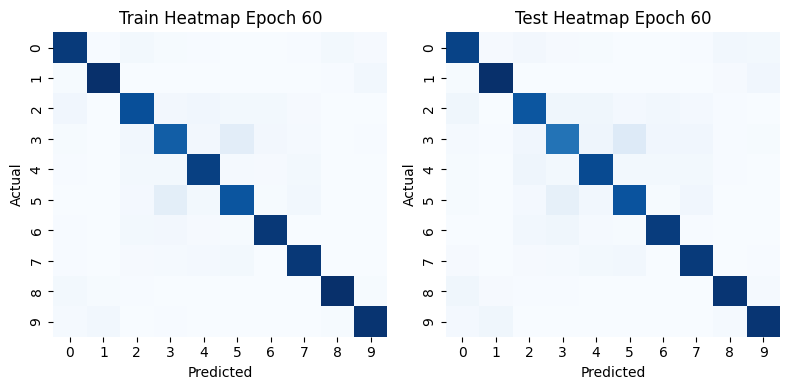

<Figure size 1200x600 with 0 Axes>

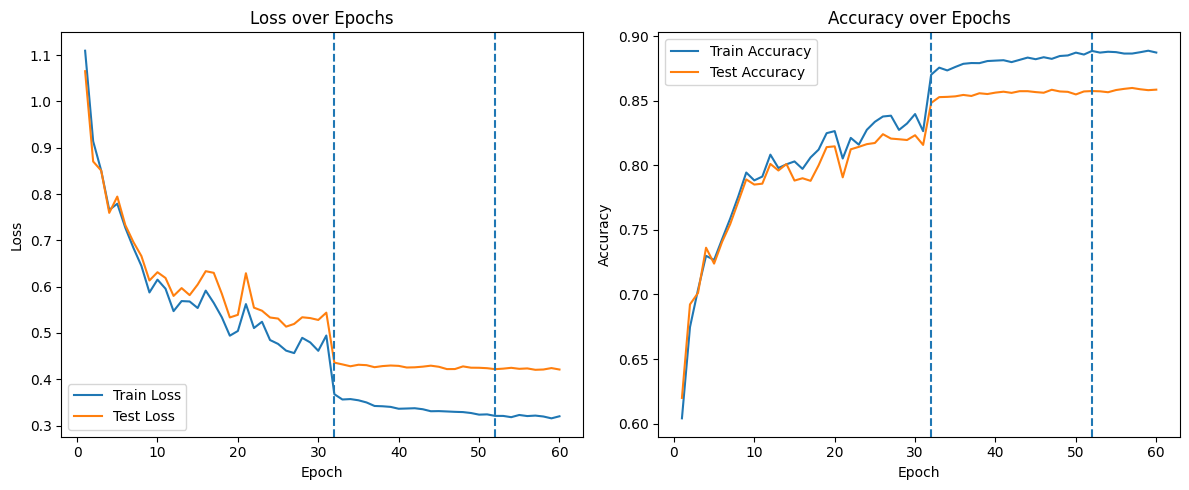

In [6]:
trainf32(model12_0,"model_weights/model12_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model12_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model12_1)
describe(model12_1)

MACs: 4.25 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16,

Loading checkpoint from model_weights/model12_1.pt
Starting
Epoch 1/60: Train loss = 1.0259, Train accuracy = 0.6333, Test loss = 1.0043, Test accuracy = 0.6395
Epoch 2/60: Train loss = 0.8514, Train accuracy = 0.6988, Test loss = 0.8373, Test accuracy = 0.7024
Epoch 3/60: Train loss = 0.7666, Train accuracy = 0.7273, Test loss = 0.7452, Test accuracy = 0.7401
Epoch 4/60: Train loss = 0.7157, Train accuracy = 0.7490, Test loss = 0.7105, Test accuracy = 0.7529
Epoch 5/60: Train loss = 0.7048, Train accuracy = 0.7583, Test loss = 0.6885, Test accuracy = 0.7652
Epoch 6/60: Train loss = 0.6631, Train accuracy = 0.7696, Test loss = 0.6913, Test accuracy = 0.7618
Epoch 7/60: Train loss = 0.6337, Train accuracy = 0.7815, Test loss = 0.6422, Test accuracy = 0.7798
Epoch 8/60: Train loss = 0.5998, Train accuracy = 0.7919, Test loss = 0.6058, Test accuracy = 0.7954
Epoch 9/60: Train loss = 0.6529, Train accuracy = 0.7693, Test loss = 0.6805, Test accuracy = 0.7646
Epoch 10/60: Train loss = 0.593

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 23/60: Train loss = 0.4716, Train accuracy = 0.8357, Test loss = 0.5133, Test accuracy = 0.8245
Epoch 24/60: Train loss = 0.4456, Train accuracy = 0.8438, Test loss = 0.4889, Test accuracy = 0.8320
Epoch 25/60: Train loss = 0.4785, Train accuracy = 0.8344, Test loss = 0.5060, Test accuracy = 0.8285
Epoch 26/60: Train loss = 0.4632, Train accuracy = 0.8377, Test loss = 0.5111, Test accuracy = 0.8243
Epoch 27/60: Train loss = 0.4939, Train accuracy = 0.8319, Test loss = 0.5579, Test accuracy = 0.8155
Epoch 28/60: Train loss = 0.4425, Train accuracy = 0.8446, Test loss = 0.4909, Test accuracy = 0.8298
Epoch 29/60: Train loss = 0.4392, Train accuracy = 0.8464, Test loss = 0.4928, Test accuracy = 0.8357
Epoch 30/60: Train loss = 0.4606, Train accuracy = 0.8413, Test loss = 0.5350, Test accuracy = 0.8208
Epoch 31/60: Train loss = 0.4358, Train accuracy = 0.8476, Test loss = 0.5072, Test accuracy = 0.8285
Epoch 32/60: Train loss = 0.3640, Train accuracy = 0.8727, Test loss = 0.4293, Tes

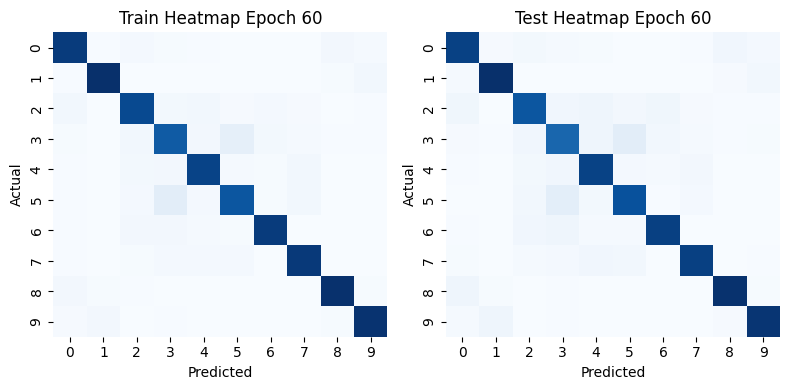

<Figure size 1200x600 with 0 Axes>

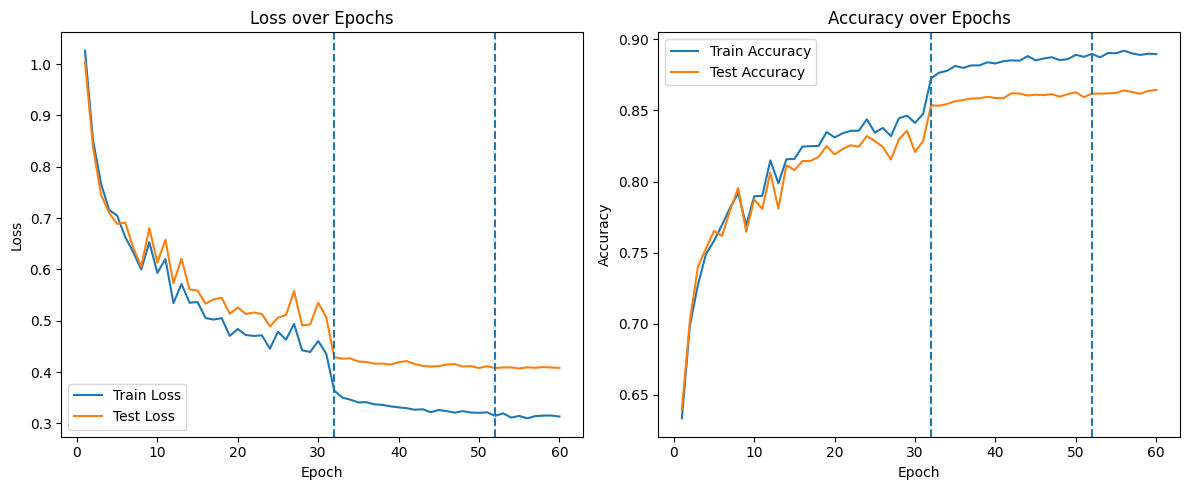

In [8]:
trainf32(model12_1,"model_weights/model12_1.pt",criterion,train_dataset,val_dataset, batch_size=64)